In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Preprocessed Data**

In [ ]:
# Load Preprocessed CSV
train_df_loaded = pd.read_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/train_preprocessed.csv')
valid_df_loaded = pd.read_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/valid_preprocessed.csv')
test_df_loaded = pd.read_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/test_preprocessed.csv')

In [ ]:
# Transform label -1 to 0
train_df_loaded['label'] = train_df_loaded['label'].map({-1: 0, 1: 1})
valid_df_loaded['label'] = valid_df_loaded['label'].map({-1: 0, 1: 1})
test_df_loaded['label'] = test_df_loaded['label'].map({-1: 0, 1: 1})


In [ ]:
# Display the first few rows to confirm successful loading
print(train_df_loaded.head())
print(valid_df_loaded.head())
print(test_df_loaded.head())

                                      processed_text  label
0                             sadly sapura touch sen      0
1                               macam mau crash kali      0
2                   tun best olwdythis malaysua fate      1
3  also lazy research jaks forum take advice tut ...      0
4  morning volume idssset block big big lalater k...      0
                                      processed_text  label
0                            q qr must bad good q qr      0
1                          trap tried lot eat minute      0
2  fata obviously armada operator still seduce so...      0
3                                      armada semput      0
4  tp jaks promoter cry find better buy price sta...      0
                                      processed_text  label
0                     sold almost mil shares already      0
1  prepared pay penalty milion star totally under...      0
2                      ugly game begin pnb bos board      0
3  pang u dont say peopleu last also tal

**Train Test Split**

In [ ]:
# Calculate the sizes of each dataset
train_size = len(train_df_loaded)
valid_size = len(valid_df_loaded)
test_size = len(test_df_loaded)

# Calculate the total size of all datasets combined
total_size = train_size + valid_size + test_size

# Proportion: 80-10-10
# Rounded values based on the total size
rounded_train_size = round(0.8 * total_size)
rounded_valid_size = round(0.1 * total_size)
rounded_test_size = total_size - rounded_train_size - rounded_valid_size  # Ensure the sum matches total_size

# Calculate adjusted proportions
train_proportion = rounded_train_size / total_size
valid_proportion = rounded_valid_size / total_size
test_proportion = rounded_test_size / total_size

# Display the adjusted dataset sizes and proportions
print(f"Train Dataset Size: {rounded_train_size} ({train_proportion:.2%})")
print(f"Validation Dataset Size: {rounded_valid_size} ({valid_proportion:.2%})")
print(f"Test Dataset Size: {rounded_test_size} ({test_proportion:.2%})")


Train Dataset Size: 1658 (80.02%)
Validation Dataset Size: 207 (9.99%)
Test Dataset Size: 207 (9.99%)


In [ ]:
# Training set
X_train = train_df_loaded['processed_text']
y_train = train_df_loaded['label']

# Validation set
X_valid = valid_df_loaded['processed_text']
y_valid = valid_df_loaded['label']

# Test set
X_test = test_df_loaded['processed_text']
y_test = test_df_loaded['label']

Install Hugging Face Transformers

In [ ]:
pip install transformers datasets

**Model Selection - XLM-R**

Load Model and Tokenizer

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=2)  # 2 labels: positive, negative


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenize the Dataset

In [ ]:
from datasets import Dataset

# Convert Pandas DataFrame to Dataset
train_dataset = Dataset.from_pandas(train_df_loaded)
valid_dataset = Dataset.from_pandas(valid_df_loaded)
test_dataset = Dataset.from_pandas(test_df_loaded)

# Tokenization
def tokenize_function(example):
    return tokenizer(example['processed_text'], truncation=True, padding="max_length", max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
valid_dataset = valid_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/1646 [00:00<?, ? examples/s]

Map:   0%|          | 0/179 [00:00<?, ? examples/s]

Map:   0%|          | 0/247 [00:00<?, ? examples/s]

**Training**

Train the Model

In [ ]:
import os
import random
import numpy as np
import torch
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Function to set random seed
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior for CUDA operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set the random seed for reproducibility
set_seed(42)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os

# Define model and tokenizer paths
MODEL_DIR = "/content/drive/MyDrive/RojakLanguageSentimentAnalysis/saved_model"
os.makedirs(MODEL_DIR, exist_ok=True)
os.environ["WANDB_DISABLED"] = "true"

try:
    # Check if saved model exists and load it
    if os.path.exists(MODEL_DIR) and os.path.exists(os.path.join(MODEL_DIR, "model.safetensors")):
        print("Loading saved model and tokenizer...")
        tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
        model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
    else:
        # If the model does not exist, raise an exception
        raise FileNotFoundError("Saved model not found. Starting training from scratch...")

except FileNotFoundError:
    # No saved model found; train a new model
    print("No saved model found. Training a new model...")
    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
    model = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=2)

    from transformers import TrainingArguments, Trainer

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        run_name="model_experiment",
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_dir="./logs",
        report_to="none",
    )

    # Define Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
    )

    # Train the model
    trainer.train()

    # Save the trained model and tokenizer
    model.save_pretrained(MODEL_DIR, safe_serialization=True)
    tokenizer.save_pretrained(MODEL_DIR)


No saved model found. Training a new model...


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,No log,0.666972
2,No log,0.602052
3,No log,0.540665


In [ ]:
# Evaluation
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset
)

Evaluate on the validation dataset

In [ ]:
# Validation predictions
print("Evaluating the model on the validation set...")
valid_predictions = trainer.predict(valid_dataset)
valid_preds = np.argmax(valid_predictions.predictions, axis=-1)
valid_labels = np.array(valid_dataset["label"])

print("Validation Classification Report:")
print(classification_report(valid_labels, valid_preds, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(valid_labels, valid_preds))

Evaluating the model on the validation set...


Validation Classification Report:
              precision    recall  f1-score   support

           0     0.8041    0.7647    0.7839       102
           1     0.7073    0.7532    0.7296        77

    accuracy                         0.7598       179
   macro avg     0.7557    0.7590    0.7567       179
weighted avg     0.7625    0.7598    0.7605       179

Confusion Matrix:
[[78 24]
 [19 58]]


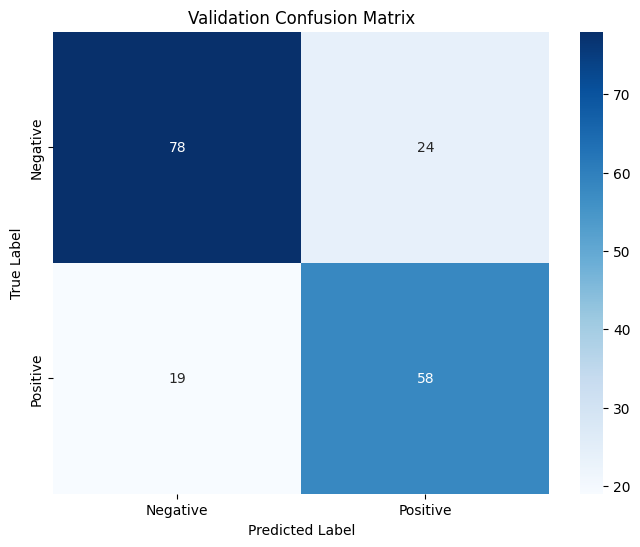

In [ ]:
# Create a confusion matrix heatmap for the validation dataset
valid_conf_matrix = confusion_matrix(valid_labels, valid_preds)  # Use validation labels and predictions
plt.figure(figsize=(8, 6))
sns.heatmap(valid_conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Validation Confusion Matrix")
plt.savefig("validation_confusion_matrix_heatmap.png")  # Save the heatmap for validation set
plt.show()


Evaluate on the test dataset

In [ ]:
# Test predictions
print("Evaluating the model on the test set...")
test_predictions = trainer.predict(test_dataset)
test_preds = np.argmax(test_predictions.predictions, axis=-1)
test_labels = np.array(test_dataset["label"])

print("Test Classification Report:")
print(classification_report(test_labels, test_preds, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(test_labels, test_preds))

Evaluating the model on the test set...


Test Classification Report:
              precision    recall  f1-score   support

           0     0.6691    0.7280    0.6973       125
           1     0.6937    0.6311    0.6609       122

    accuracy                         0.6802       247
   macro avg     0.6814    0.6796    0.6791       247
weighted avg     0.6813    0.6802    0.6794       247

Confusion Matrix:
[[91 34]
 [45 77]]


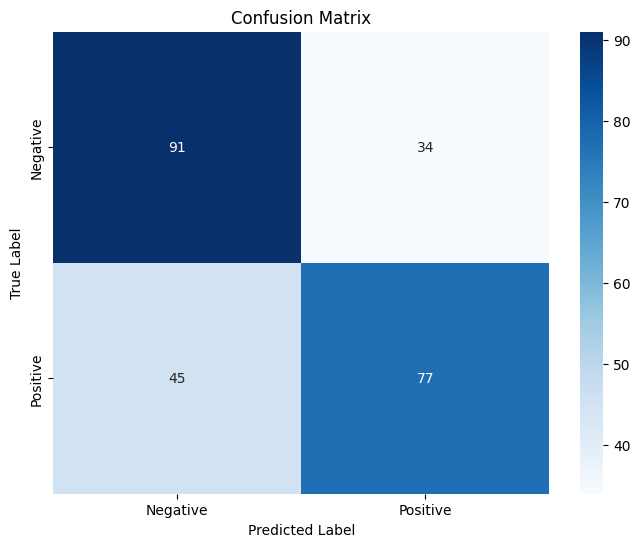

In [ ]:
# Create a confusion matrix heatmap for test dataset
conf_matrix = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix_heatmap.png")  # Save the heatmap
plt.show()




---


**Hyperparameter Tuning**

Prepare data for tuning

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 14.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
import os
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# Function to set random seed
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Define paths
MODEL_DIR = "/content/drive/MyDrive/RojakLanguageSentimentAnalysis/saved_model"
DATA_DIR = "/content/drive/MyDrive/RojakLanguageSentimentAnalysis"
RESULTS_FILE = "/content/drive/MyDrive/RojakLanguageSentimentAnalysis/tuningResults.csv"

os.makedirs(MODEL_DIR, exist_ok=True)
os.environ["WANDB_DISABLED"] = "true"

# Load preprocessed datasets
def load_datasets():
    train_df = pd.read_csv(os.path.join(DATA_DIR, "train_preprocessed.csv"))
    valid_df = pd.read_csv(os.path.join(DATA_DIR, "valid_preprocessed.csv"))
    test_df = pd.read_csv(os.path.join(DATA_DIR, "test_preprocessed.csv"))

    # Transform labels
    for df in [train_df, valid_df, test_df]:
        df['label'] = df['label'].map({-1: 0, 1: 1})

    # Convert to HuggingFace Dataset
    train_dataset = Dataset.from_pandas(train_df)
    valid_dataset = Dataset.from_pandas(valid_df)
    test_dataset = Dataset.from_pandas(test_df)

    return train_dataset, valid_dataset, test_dataset

train_dataset, valid_dataset, test_dataset = load_datasets()

In [ ]:
# Tokenizer and model loading
def load_model_and_tokenizer(model_dir=MODEL_DIR):
    if os.path.exists(os.path.join(model_dir, "config.json")):
        print("Loading saved model and tokenizer...")
        tokenizer = AutoTokenizer.from_pretrained(model_dir)
        model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    else:
        print("No saved model found. Loading base model...")
        tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
        model = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=2)
    return tokenizer, model

tokenizer, model = load_model_and_tokenizer()

# Tokenization function
def tokenize_function(example):
    return tokenizer(example['processed_text'], truncation=True, padding="max_length", max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
valid_dataset = valid_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

No saved model found. Loading base model...


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/1646 [00:00<?, ? examples/s]

Map:   0%|          | 0/179 [00:00<?, ? examples/s]

Map:   0%|          | 0/247 [00:00<?, ? examples/s]

Hyperparameter tuning

In [ ]:
# Training and evaluation
def train_and_evaluate(learning_rate, num_epochs, batch_size):
    global best_accuracy

    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        logging_dir="./logs",
        report_to="none",
        save_total_limit=1,
        load_best_model_at_end=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset
    )

    print(f"Training with LR={learning_rate}, Epochs={num_epochs}, Batch Size={batch_size}")
    trainer.train()

    valid_predictions = trainer.predict(valid_dataset)
    valid_preds = np.argmax(valid_predictions.predictions, axis=-1)
    valid_labels = np.array(valid_dataset["label"])
    accuracy = (valid_preds == valid_labels).mean()

    print(f"Validation Accuracy: {accuracy:.4f}")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        print("New best model found! Saving...")
        model.save_pretrained(MODEL_DIR)
        tokenizer.save_pretrained(MODEL_DIR)

    return accuracy

In [ ]:
# Save results to CSV
def save_results_to_csv(results, file_path):
    results_df = pd.DataFrame([results])
    if os.path.exists(file_path):
        results_df.to_csv(file_path, mode='a', header=False, index=False)
    else:
        results_df.to_csv(file_path, mode='w', header=True, index=False)

# Load previous results
def load_results(file_path):
    if os.path.exists(file_path):
        return pd.read_csv(file_path)
    else:
        return pd.DataFrame(columns=["learning_rate", "epochs", "batch_size", "accuracy"])

previous_results = load_results(RESULTS_FILE)
best_accuracy = previous_results["accuracy"].max() if not previous_results.empty else 0

In [ ]:
# Hyperparameter tuning
def tune_hyperparameters(learning_rate, num_epochs, batch_size):
    if any(previous_results[['learning_rate', 'epochs', 'batch_size']].eq([learning_rate, num_epochs, batch_size]).all(axis=1)):
        print(f"Combination (LR={learning_rate}, Epochs={num_epochs}, Batch Size={batch_size}) already evaluated. Skipping.")
        return

    try:
        accuracy = train_and_evaluate(learning_rate, num_epochs, batch_size)
        results = {"learning_rate": learning_rate, "epochs": num_epochs, "batch_size": batch_size, "accuracy": accuracy}
        save_results_to_csv(results, RESULTS_FILE)
        print(f"Saved results: LR={learning_rate}, Epochs={num_epochs}, Batch Size={batch_size}, Accuracy={accuracy:.4f}")
    except Exception as e:
        print(f"Error with LR={learning_rate}, Epochs={num_epochs}, Batch Size={batch_size}: {e}")

In [ ]:
# Initialize results and best accuracy
results = [
    ("Initial Model", "2e-5", 3, 16, 0.7598)  # Log initial model
]
best_accuracy = 0.7598
best_model = model
best_learning_rate = 2e-5
best_num_epochs = 3
best_batch_size = 16

In [ ]:
# Hyperparameter Tuning
learning_rates = [3e-5, 5e-5]
num_epochs = [3, 4]
batch_sizes = [16, 32]

In [ ]:
# Function for hyperparameter tuning
for learning_rate in learning_rates:
    for num_epoch in num_epochs:
        for batch_size in batch_sizes:
            tune_hyperparameters(learning_rate=learning_rate, num_epochs=num_epoch, batch_size=batch_size)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Training with LR=3e-05, Epochs=3, Batch Size=16


Epoch,Training Loss,Validation Loss
1,No log,0.664630
2,No log,0.480894
3,No log,0.445900


Validation Accuracy: 0.8436
New best model found! Saving...
Saved results: LR=3e-05, Epochs=3, Batch Size=16, Accuracy=0.8436
Training with LR=3e-05, Epochs=3, Batch Size=32


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


...

Epoch,Training Loss,Validation Loss
1,No log,0.612238
2,No log,0.660766
3,No log,0.732300
4,No log,0.874580


Validation Accuracy: 0.7989
Saved results: LR=5e-05, Epochs=4, Batch Size=16, Accuracy=0.7989
Training with LR=5e-05, Epochs=4, Batch Size=32


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,No log,0.607519
2,No log,0.728642
3,No log,0.650147
4,No log,0.706128


Validation Accuracy: 0.8045
Saved results: LR=5e-05, Epochs=4, Batch Size=32, Accuracy=0.8045


In [ ]:
# Print all results
print("Hyperparameter Tuning Results:")
for result in results:
    if result[0] == "Initial Model":
        print(f"Initial Model -> Learning Rate: {result[1]}, Epochs: {result[2]}, Batch Size: {result[3]}, Accuracy: {result[4]:.4f}")
    else:
        print(f"Learning Rate: {result[0]}, Epochs: {result[1]}, Batch Size: {result[2]}, Accuracy: {result[3]:.4f}")

print(f"Best Model Accuracy: {best_accuracy:.4f}")

Hyperparameter Tuning Results:
Initial Model -> Learning Rate: 2e-5, Epochs: 3, Batch Size: 16, Accuracy: 0.7598
Best Model Accuracy: 0.8436



Evaluating the Best Model on the Test Set...


Test Classification Report:
              precision    recall  f1-score   support

           0     0.7252    0.7600    0.7422       125
           1     0.7414    0.7049    0.7227       122

    accuracy                         0.7328       247
   macro avg     0.7333    0.7325    0.7324       247
weighted avg     0.7332    0.7328    0.7326       247



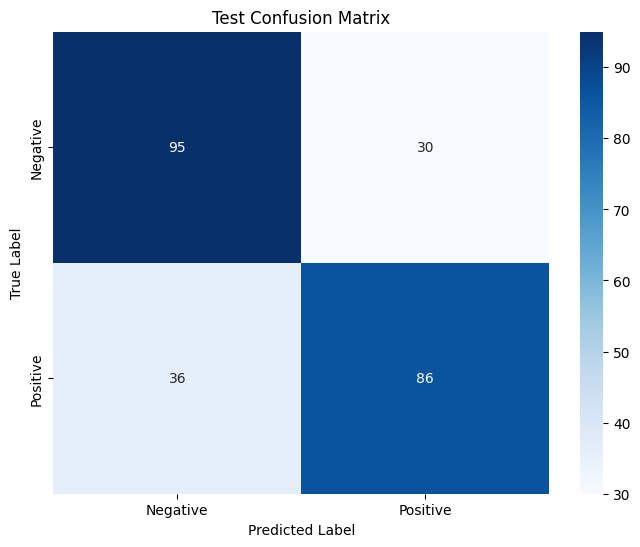

In [ ]:
# Evaluate on Test Set with Best Parameters
print("\nEvaluating the Best Model on the Test Set...")

# Define the training arguments again for evaluation (no training, just evaluation)
test_args = TrainingArguments(
    output_dir="./test_results",
    per_device_eval_batch_size=32,  # batch size
    do_train=False,  # Disable training for evaluation
    do_eval=True,    # Enable evaluation
    eval_strategy="no",  # only testing
    logging_dir="./logs",
    report_to="none",  # Disable WANDB and other logging integrations
)

# Trainer for evaluation
test_trainer = Trainer(model=best_model, args=test_args, eval_dataset=test_dataset)

# Test predictions
test_predictions = test_trainer.predict(test_dataset)
test_preds = np.argmax(test_predictions.predictions, axis=-1)
test_labels = np.array(test_dataset["label"])

# Generate classification report
print("Test Classification Report:")
print(classification_report(test_labels, test_preds, digits=4))

# Generate confusion matrix
conf_matrix = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Test Confusion Matrix")
plt.show()


Hyperparameter Tuning Results:
   learning_rate  epochs  batch_size  accuracy
0        0.00003       3          16  0.843575
1        0.00003       3          32  0.821229
2        0.00003       4          16  0.798883
3        0.00003       4          32  0.787709
4        0.00005       3          16  0.743017
5        0.00005       3          32  0.782123
6        0.00005       4          16  0.798883
7        0.00005       4          32  0.804469


<ipython-input-6-58389ae2c48d>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tuning_results, x="combination", y="accuracy", palette="viridis")


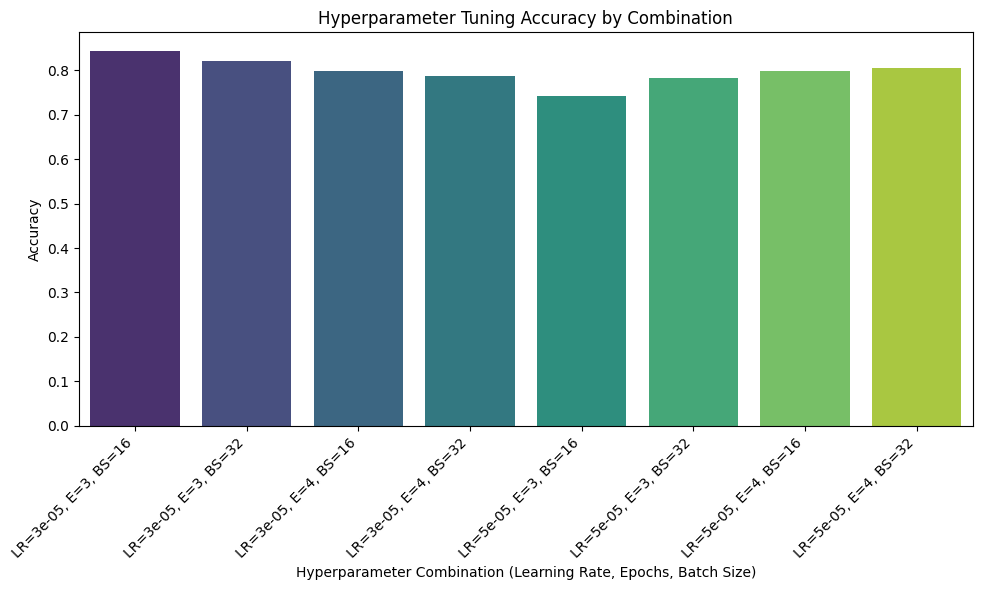

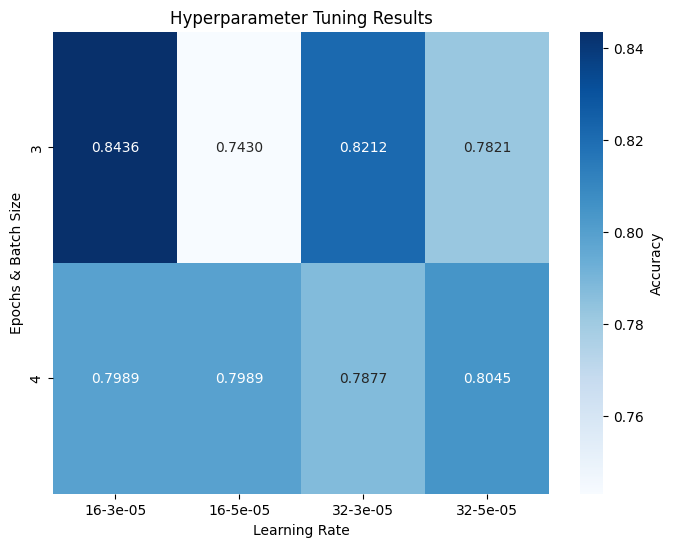

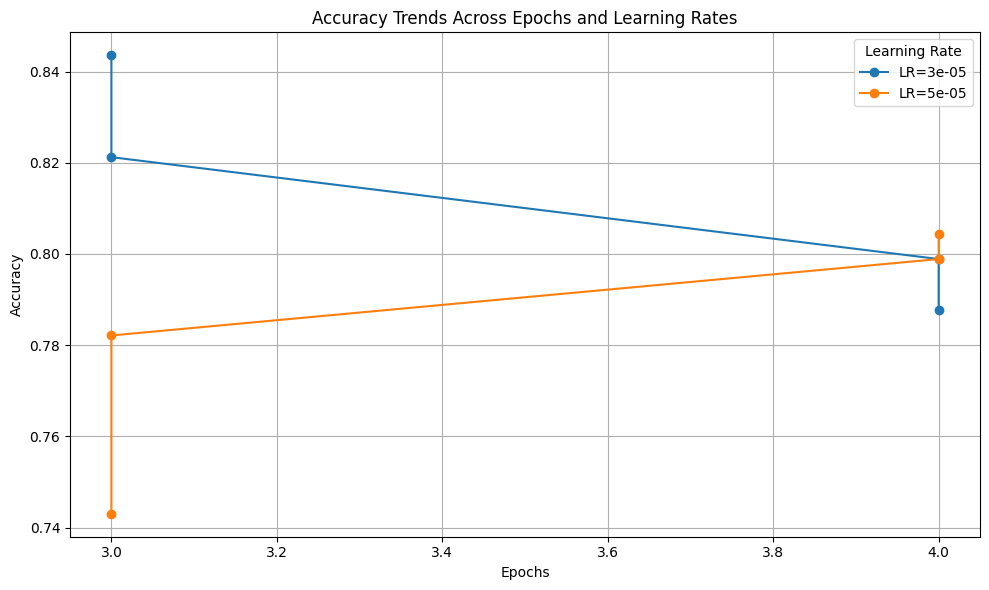

In [ ]:
# Load the results from the CSV file
tuning_results = pd.read_csv("/content/drive/MyDrive/RojakLanguageSentimentAnalysis/tuningResults.csv")

# Tuning results csv
print("Hyperparameter Tuning Results:")
print(tuning_results)

# Generate Bar Chart for Hyperparameter Tuning Results
plt.figure(figsize=(10, 6))
tuning_results["combination"] = (
    "LR=" + tuning_results["learning_rate"].astype(str) +
    ", E=" + tuning_results["epochs"].astype(str) +
    ", BS=" + tuning_results["batch_size"].astype(str)
)
sns.barplot(data=tuning_results, x="combination", y="accuracy", palette="viridis")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.title("Hyperparameter Tuning Accuracy by Combination")
plt.xlabel("Hyperparameter Combination (Learning Rate, Epochs, Batch Size)")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# Pivot the dataframe to get the combinations of learning rates, epochs, and batch sizes
pivoted = tuning_results.pivot_table(
    index="epochs",
    columns=["batch_size", "learning_rate"],
    values="accuracy",
)

# Create a heatmap to visualize the results
plt.figure(figsize=(8, 6))
sns.heatmap(pivoted, annot=True, cmap="Blues", fmt=".4f", cbar_kws={'label': 'Accuracy'})
plt.title("Hyperparameter Tuning Results")
plt.ylabel("Epochs & Batch Size")
plt.xlabel("Learning Rate")
plt.show()


# Generate a Line Plot to Analyze Accuracy Trends
plt.figure(figsize=(10, 6))
for lr in tuning_results["learning_rate"].unique():
    subset = tuning_results[tuning_results["learning_rate"] == lr]
    plt.plot(subset["epochs"], subset["accuracy"], marker='o', label=f"LR={lr}")
plt.title("Accuracy Trends Across Epochs and Learning Rates")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(title="Learning Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Save the best model and tokenizer for future use
best_model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print(f"Best model saved to {MODEL_DIR}")

Best model saved to /content/drive/MyDrive/RojakLanguageSentimentAnalysis/saved_model




---


**Human-Level Performance**

In [ ]:
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, cohen_kappa_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from tqdm import tqdm
from datasets import Dataset

In [ ]:
# Load Preprocessed Data
train_path = "/content/drive/MyDrive/RojakLanguageSentimentAnalysis/hlp_train_preprocessed.csv"
valid_path = "/content/drive/MyDrive/RojakLanguageSentimentAnalysis/hlp_valid_preprocessed.csv"
test_path = "/content/drive/MyDrive/RojakLanguageSentimentAnalysis/hlp_test_preprocessed.csv"
MODEL_DIR = "/content/drive/MyDrive/RojakLanguageSentimentAnalysis/saved_model"

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)
test_df = pd.read_csv(test_path)

# Transform label -1 to 0
train_df['label'] = train_df['label'].map({-1: 0, 1: 1})
valid_df['label'] = valid_df['label'].map({-1: 0, 1: 1})
test_df['label'] = test_df['label'].map({-1: 0, 1: 1})

# Load model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)


In [ ]:
# Prepare Datasets and Tokenize
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# Convert DataFrame to HuggingFace Dataset
train_dataset_hlp = Dataset.from_pandas(train_df)
valid_dataset_hlp = Dataset.from_pandas(valid_df)
test_dataset_hlp = Dataset.from_pandas(test_df)

# Tokenization function for the HLP datasets
def tokenize_function(example):
    return tokenizer(example['processed_text'], truncation=True, padding="max_length", max_length=128)

# Apply tokenization to the datasets
train_dataset_hlp = train_dataset_hlp.map(tokenize_function, batched=True)
valid_dataset_hlp = valid_dataset_hlp.map(tokenize_function, batched=True)
test_dataset_hlp = test_dataset_hlp.map(tokenize_function, batched=True)


Map:   0%|          | 0/518 [00:00<?, ? examples/s]

Map:   0%|          | 0/58 [00:00<?, ? examples/s]

Map:   0%|          | 0/113 [00:00<?, ? examples/s]

In [ ]:
# Evaluation Function for Human Level Performance (HLP)
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, cohen_kappa_score

# Custom collate function to ensure batch is formatted correctly
def collate_fn(batch):
    # Ensure the batch is a dictionary of tensors
    input_ids = torch.tensor([item['input_ids'] for item in batch])  # Convert list to tensor
    attention_mask = torch.tensor([item['attention_mask'] for item in batch])  # Convert list to tensor
    labels = torch.tensor([item['label'] for item in batch])  # Convert list to tensor

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'label': labels
    }

# Evaluation function for Human Level Performance (HLP)
def evaluate_hlp(model, dataset, batch_size=32):
    # Create DataLoader for evaluation with custom collate function
    dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn)

    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []

    # Inference loop
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating HLP..."):
            # Move inputs and labels to the correct device
            inputs = {key: value.to(model.device) for key, value in batch.items() if key != 'label'}
            labels = batch['label'].to(model.device)

            outputs = model(**inputs)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

# Evaluate model on the validation set and compare it with human-level performance
valid_preds_hlp, valid_labels_hlp = evaluate_hlp(model, valid_dataset_hlp)

# Print classification report and Cohen's Kappa score
print("Validation Classification Report:")
print(classification_report(valid_labels_hlp, valid_preds_hlp, digits=4))

print("Cohen's Kappa Score for Validation:")
print(cohen_kappa_score(valid_labels_hlp, valid_preds_hlp))


Evaluating HLP...: 100%|██████████| 2/2 [00:37<00:00, 18.89s/it]

Validation Classification Report:
              precision    recall  f1-score   support

           0     0.8889    0.8421    0.8649        38
           1     0.7273    0.8000    0.7619        20

    accuracy                         0.8276        58
   macro avg     0.8081    0.8211    0.8134        58
weighted avg     0.8332    0.8276    0.8294        58

Cohen's Kappa Score for Validation:
0.6272493573264781


In [ ]:
# Evaluate model on the test set for HLP comparison
test_preds_hlp, test_labels_hlp = evaluate_hlp(model, test_dataset_hlp)

# Print classification report and Cohen's Kappa score
print("Test Classification Report:")
print(classification_report(test_labels_hlp, test_preds_hlp, digits=4))

print("Cohen's Kappa Score for Test:")
print(cohen_kappa_score(test_labels_hlp, test_preds_hlp))


Evaluating HLP...: 100%|██████████| 4/4 [00:51<00:00, 12.89s/it]

Test Classification Report:
              precision    recall  f1-score   support

           0     0.6429    0.7895    0.7087        57
           1     0.7209    0.5536    0.6263        56

    accuracy                         0.6726       113
   macro avg     0.6819    0.6715    0.6675       113
weighted avg     0.6815    0.6726    0.6678       113

Cohen's Kappa Score for Test:
0.3437450949615445


In [ ]:
# Save classification reports to CSV
def save_classification_report(predictions, labels, output_file):
    report = classification_report(labels, predictions, output_dict=True)
    pd.DataFrame(report).to_csv(output_file, index=True)

# Save classification reports for validation and test
save_classification_report(valid_preds_hlp, valid_labels_hlp, "/content/drive/MyDrive/RojakLanguageSentimentAnalysis/hlp_valid_classification_report.csv")
save_classification_report(test_preds_hlp, test_labels_hlp, "/content/drive/MyDrive/RojakLanguageSentimentAnalysis/hlp_test_classification_report.csv")

# Save Kappa scores
with open("/content/drive/MyDrive/RojakLanguageSentimentAnalysis/hlp_kappa_scores.txt", "w") as f:
    f.write(f"Validation Cohen's Kappa: {cohen_kappa_score(valid_labels_hlp, valid_preds_hlp)}\n")
    f.write(f"Test Cohen's Kappa: {cohen_kappa_score(test_labels_hlp, test_preds_hlp)}\n")
